<a href="https://colab.research.google.com/github/mr-chaitanyad/MLDL-Experiments/blob/master/MLDL_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MLDL Lab No. 1**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving student_performance.csv to student_performance (3).csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_performance.csv")
df.head()


,Hours_Studied,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,1,60,55,50,52
1,2,65,58,55,57
2,3,70,60,58,60
3,4,75,65,62,64
4,5,80,68,65,68


In [ ]:
final_scores = np.array(df["Final_Score"])
final_scores


array([52, 57, 60, 64, 68, 71, 74, 77, 79, 83, 63, 70, 75, 56, 69, 73, 80,
       58, 72, 78])

In [ ]:
print("Mean:", np.mean(final_scores))
print("Median:", np.median(final_scores))
print("Standard Deviation:", np.std(final_scores))


Mean: 68.95
Median: 70.5
Standard Deviation: 8.71478628538876


In [ ]:
normalized_scores = (final_scores - np.min(final_scores)) / (np.max(final_scores) - np.min(final_scores))
normalized_scores


array([0.        , 0.16129032, 0.25806452, 0.38709677, 0.51612903,
       0.61290323, 0.70967742, 0.80645161, 0.87096774, 1.        ,
       0.35483871, 0.58064516, 0.74193548, 0.12903226, 0.5483871 ,
       0.67741935, 0.90322581, 0.19354839, 0.64516129, 0.83870968])

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns)
print("Missing Values:\n", df.isnull().sum())


Shape: (20, 5)
Columns: Index(['Hours_Studied', 'Attendance', 'Assignment_Score', 'Midterm_Score',
       'Final_Score'],
      dtype='object')
Missing Values:
 Hours_Studied       0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


In [ ]:
df["Performance"] = df["Final_Score"].apply(
    lambda x: "Pass" if x >= 60 else "Fail"
)

df


,Hours_Studied,Attendance,Assignment_Score,Midterm_Score,Final_Score,Performance
0,1,60,55,50,52,Fail
1,2,65,58,55,57,Fail
2,3,70,60,58,60,Pass
3,4,75,65,62,64,Pass
4,5,80,68,65,68,Pass
5,6,85,72,68,71,Pass
6,7,90,75,70,74,Pass
7,8,95,78,72,77,Pass
8,9,88,80,75,79,Pass
9,10,92,85,78,83,Pass


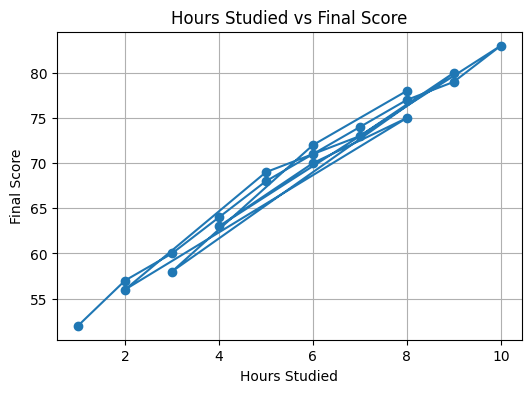

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(df["Hours_Studied"], df["Final_Score"], marker='o')
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.title("Hours Studied vs Final Score")
plt.grid(True)
plt.show()


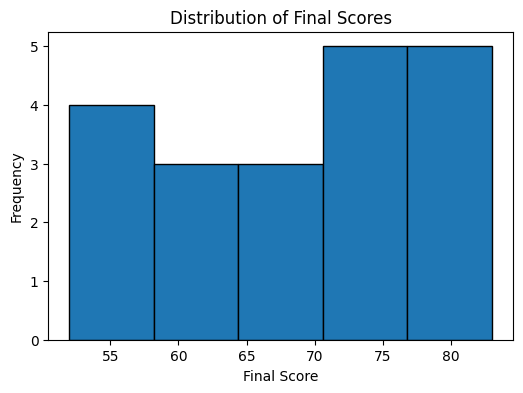

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Final_Score"], bins=5, edgecolor='black')
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.title("Distribution of Final Scores")
plt.show()


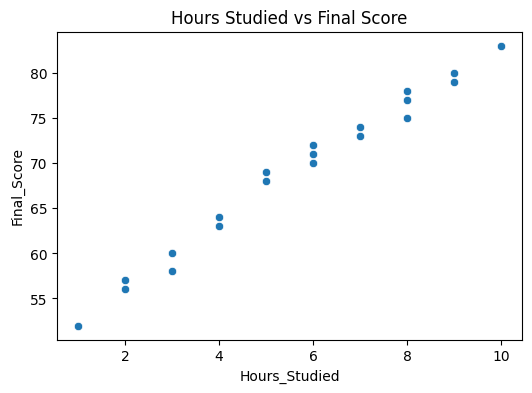

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Hours_Studied", y="Final_Score", data=df)
plt.title("Hours Studied vs Final Score")
plt.show()


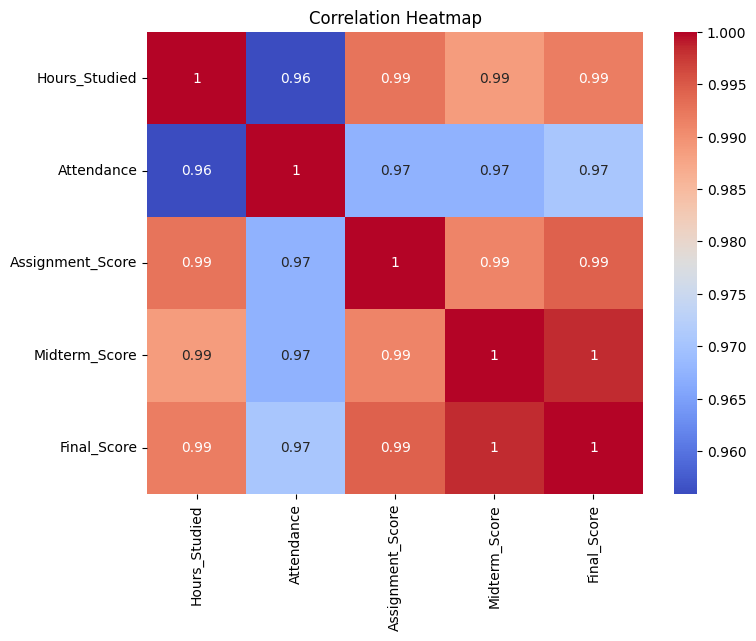

In [ ]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


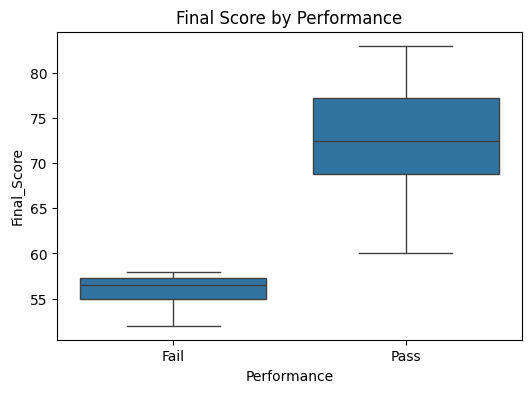

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Performance", y="Final_Score", data=df)
plt.title("Final Score by Performance")
plt.show()


# **MLDL Lab No. 1**

In [ ]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 2: Create synthetic dataset
np.random.seed(42)
X = np.random.randn(100, 5)
true_coef = np.array([3, -1.5, 0, 0, 2])
y = X @ true_coef + np.random.randn(100) * 2  # add noise

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Fit Ridge Regression model
ridge = Ridge(alpha=1.0)  # alpha = λ
ridge.fit(X_train, y_train)

# Step 5: Predictions
y_pred = ridge.predict(X_test)

# Step 6: Results
print("Ridge Coefficients:", ridge.coef_)
print("Intercept:", ridge.intercept_)
print("Test MSE:", mean_squared_error(y_test, y_pred))


Ridge Coefficients: [ 3.25091823 -1.29690167  0.06694325  0.09046002  1.97027418]
Intercept: -0.22603190602824982
Test MSE: 3.921461679459078


# **MLDL Lab No. 4**

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Load diabetes dataset from scikit-learn
diabetes = load_diabetes()

X = diabetes.data      # Features
y = diabetes.target    # Target (disease progression)

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 442
Number of features: 10


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# R² Score
r2 = `(y_test, y_pred)
print("R² Score:", r2)

Mean Squared Error: 3047.449887640449
R² Score: 0.42480887066066253


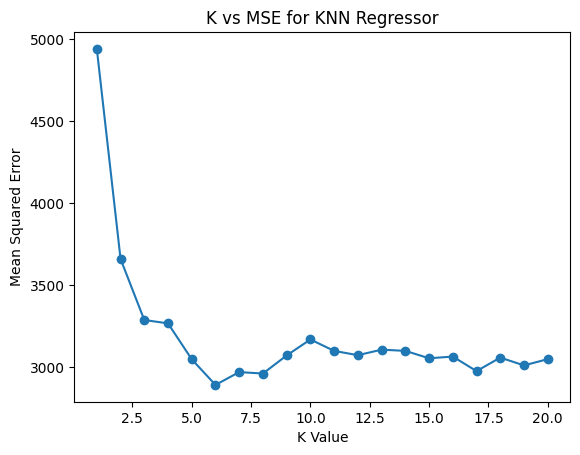

In [ ]:
#Optional

mse_values = []

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    mse_values.append(mean_squared_error(y_test, y_pred_k))

plt.plot(range(1, 21), mse_values, marker='o')
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error")
plt.title("K vs MSE for KNN Regressor")
plt.show()

# **MLDL Lab No. 3**

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
newsgroups = fetch_20newsgroups(subset='all', shuffle=True, random_state=42)

X = newsgroups.data   # text documents
y = newsgroups.target # class labels

print("Number of samples:", len(X))
print("Number of classes:", len(newsgroups.target_names))

Number of samples: 18846
Number of classes: 20


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.5)
X_vectorized = vectorizer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)


In [ ]:
# --- Decision Tree ---

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.66657824933687
Decision Tree Report:
               precision    recall  f1-score   support

           0       0.57      0.54      0.55       151
           1       0.53      0.51      0.52       202
           2       0.58      0.64      0.61       195
           3       0.46      0.49      0.47       183
           4       0.70      0.61      0.65       205
           5       0.60      0.55      0.58       215
           6       0.76      0.69      0.72       193
           7       0.69      0.67      0.68       196
           8       0.75      0.78      0.77       168
           9       0.72      0.72      0.72       211
          10       0.81      0.77      0.79       198
          11       0.81      0.78      0.80       201
          12       0.49      0.51      0.50       202
          13       0.71      0.70      0.70       194
          14       0.74      0.80      0.77       189
          15       0.78      0.79      0.79       202
          16     

In [ ]:
# --- Random Forest ---

rforest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rforest.fit(X_train, y_train)
y_pred_rf = rforest.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8769230769230769
Random Forest Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87       151
           1       0.76      0.87      0.81       202
           2       0.77      0.88      0.82       195
           3       0.71      0.73      0.72       183
           4       0.88      0.88      0.88       205
           5       0.91      0.82      0.87       215
           6       0.78      0.83      0.80       193
           7       0.91      0.90      0.90       196
           8       0.96      0.93      0.95       168
           9       0.94      0.95      0.94       211
          10       0.94      0.98      0.96       198
          11       0.95      0.97      0.96       201
          12       0.91      0.72      0.80       202
          13       0.93      0.90      0.91       194
          14       0.91      0.96      0.93       189
          15       0.81      1.00      0.89       202
          16   

# **MLDL Lab No. 7**

Saving diabetes.csv to diabetes.csv
Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5988 - loss: 0.6856 - val_accuracy: 0.6179 - val_loss: 0.6737
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6477 - loss: 0.6502 - val_accuracy: 0.6423 - val_loss: 0.6383
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6375 - loss: 0.6257 - val_accuracy: 0.6504 - val_loss: 0.6075
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6843 - loss: 0.5741 - val_accuracy: 0.6748 - val_loss: 0.5845
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7026 - loss: 0.5673 - val_accuracy: 0.7073 - val_loss: 0.5672
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6904 - loss: 0.5562 - val_accuracy: 0.7236 - val_loss: 0.5497
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7271 - loss: 0.5428 - val_accuracy: 0.7398 - val_loss: 0.5354
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7332 - lo

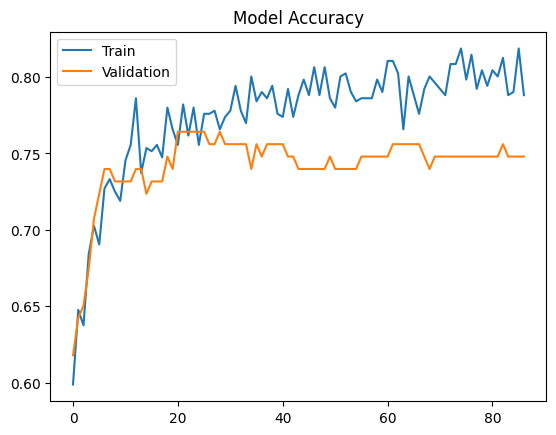

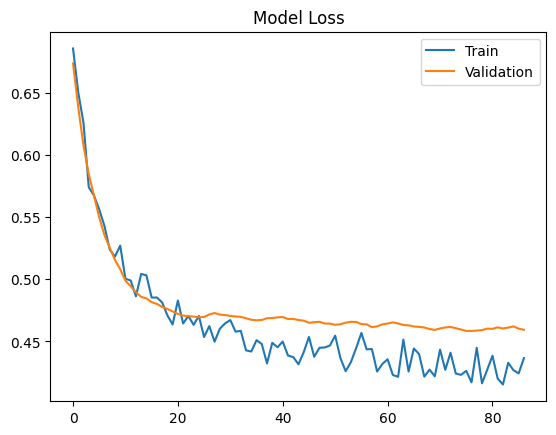

In [ ]:
# ============================
# IMPROVED ANN MODEL
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files

# Load Dataset (Directly)
uploaded = files.upload()

data = pd.read_csv("/content/diabetes.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Improved Model with Dropout (to reduce overfitting)
model = keras.Sequential([
    keras.Input(shape=(8,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test)
print("\nImproved Test Accuracy:", accuracy)

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train','Validation'])
plt.show()

# Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train','Validation'])
plt.show()


# **MLDL Lab No. 8**

TensorFlow : 2.19.0
GPU        : []

Loading mnist ...
Train : (10000, 28, 28, 1)  |  Test : (10000, 28, 28, 1)
Classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


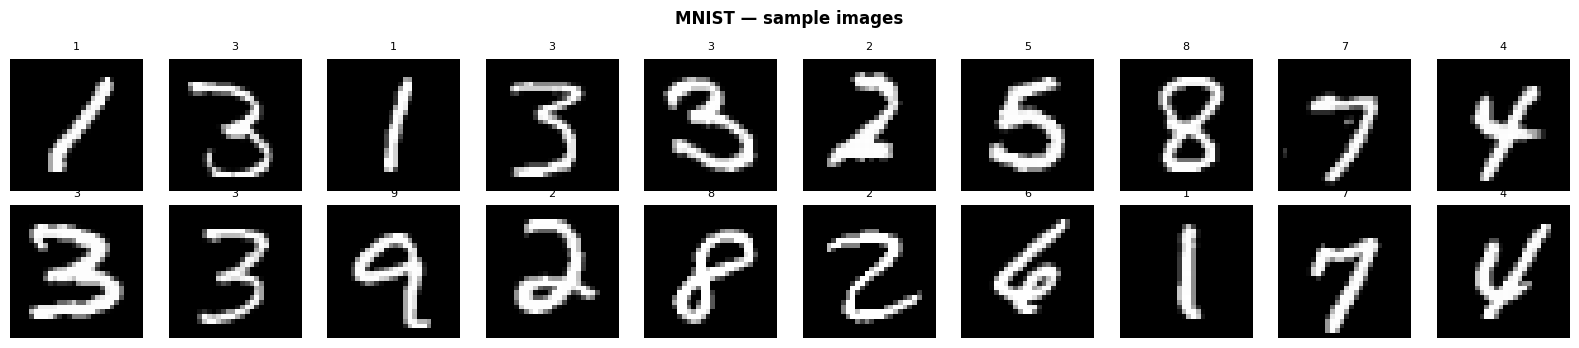

Model: "Medium_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)


Training medium on mnist ...
Epoch 1/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6907 - loss: 1.0379
Epoch 1: val_accuracy improved from None to 0.11350, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 173ms/step - accuracy: 0.8479 - loss: 0.4943 - val_accuracy: 0.1135 - val_loss: 2.6987 - learning_rate: 0.0010
Epoch 2/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9484 - loss: 0.1640
Epoch 2: val_accuracy improved from 0.11350 to 0.37190, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - accuracy: 0.9545 - loss: 0.1451 - val_accuracy: 0.3719 - val_loss: 1.5905 - learning_rate: 0.0010
Epoch 3/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9722 - loss: 0.0943
Epoch 3: val_accuracy improved from 0.37190 to 0.84460, saving model to best_model.keras

Epoch 3: finished saving model to best_model.kera

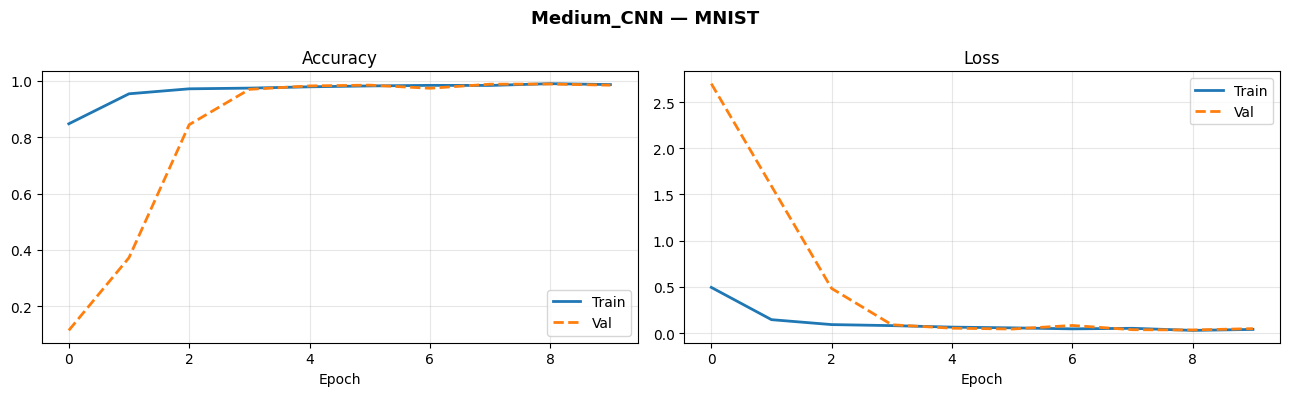


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



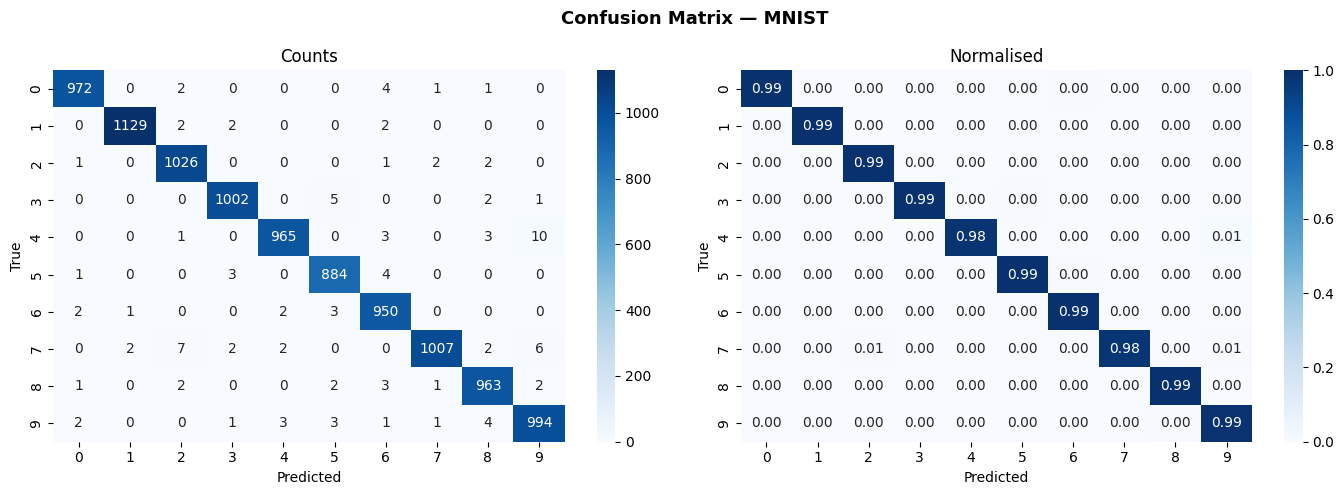

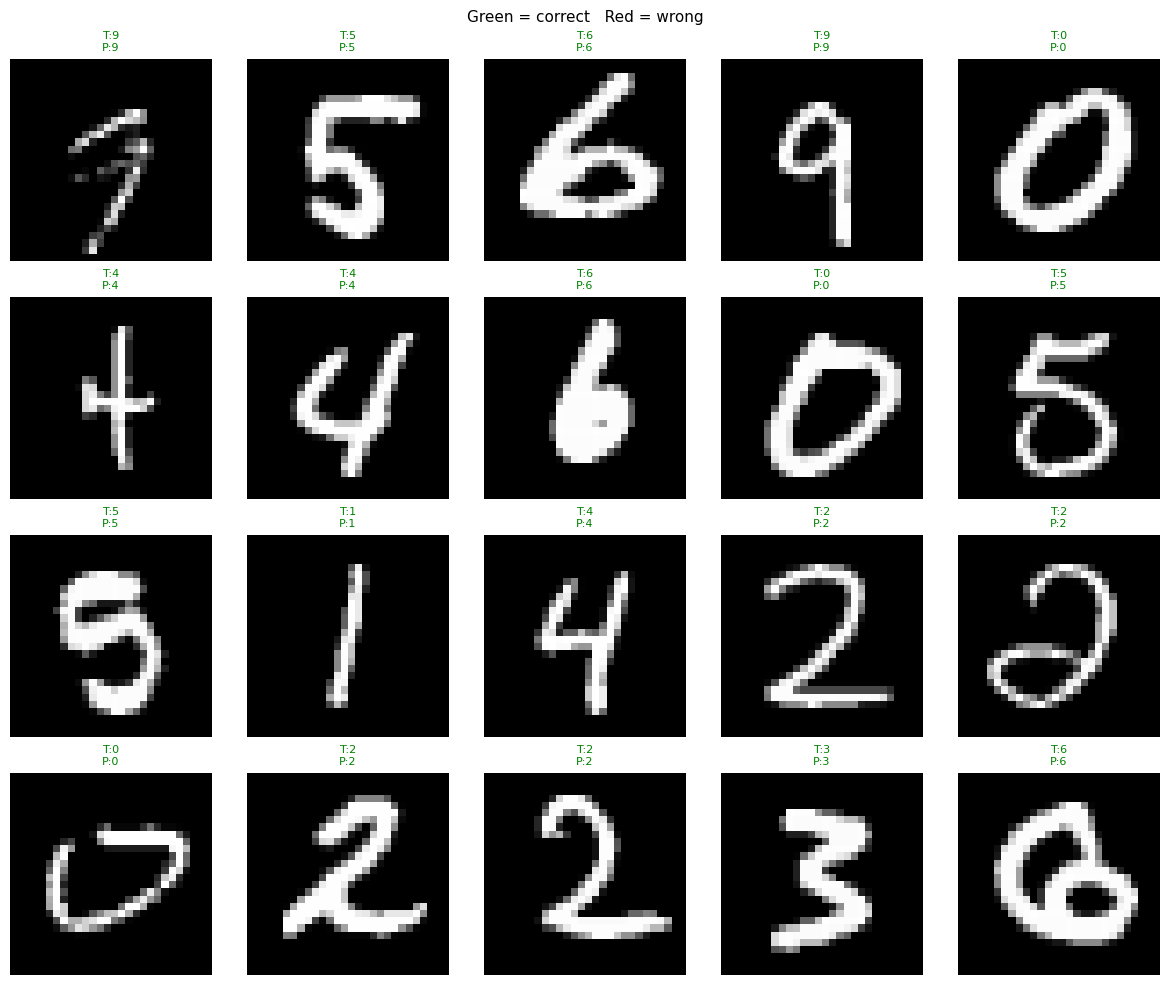

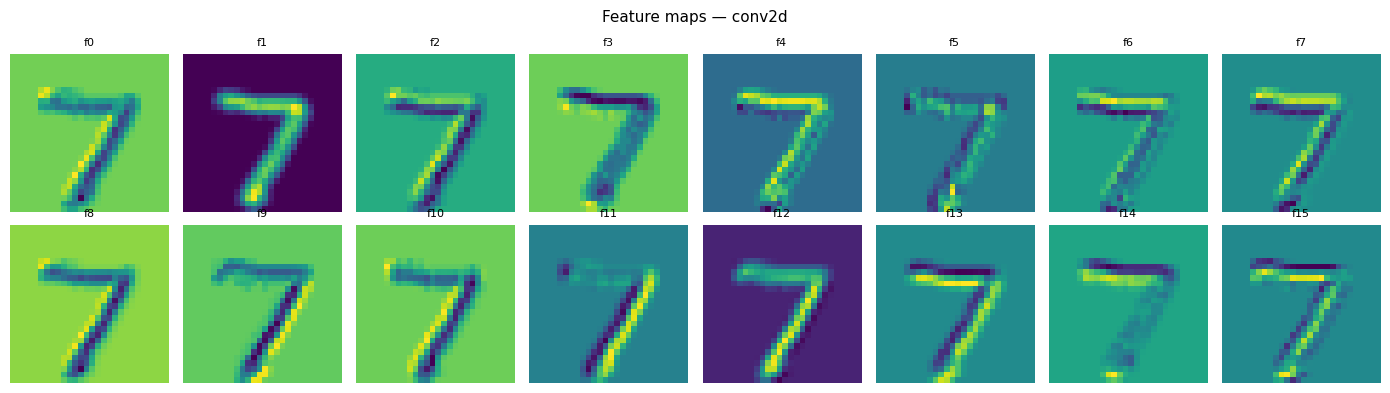

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: sample_predictions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: feature_maps.png

🎉 All done!


In [ ]:
# ============================================================
#  CNN TRAINER — Paste this entire cell into Google Colab
#  Runtime → Change runtime type → T4 GPU  (recommended)
# ============================================================

# ── 0. Install ──────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "-q", "seaborn", "scikit-learn"], check=True)

# ── 1. Imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

# ── 2. CONFIG — edit these ───────────────────────────────────
DATASET   = "mnist"    # "mnist" | "fashion" | "cifar10"
ARCH      = "medium"   # "simple" | "medium" | "deep" | "lenet"
EPOCHS    = 10
BATCH     = 64
LR        = 0.001
OPTIMIZER = "adam"     # "adam" | "sgd" | "rmsprop" | "adamax"
DROPOUT   = 0.5
AUGMENT   = False
SAMPLES   = 10000      # set None to use all 60 000

# ── 3. Labels ────────────────────────────────────────────────
LABELS = {
    "mnist"  : [str(i) for i in range(10)],
    "fashion": ["T-shirt","Trouser","Pullover","Dress","Coat",
                "Sandal","Shirt","Sneaker","Bag","Ankle boot"],
    "cifar10": ["Airplane","Automobile","Bird","Cat","Deer",
                "Dog","Frog","Horse","Ship","Truck"],
}

# ── 4. Load data ─────────────────────────────────────────────
print(f"\nLoading {DATASET} ...")
loaders = {
    "mnist"  : keras.datasets.mnist,
    "fashion": keras.datasets.fashion_mnist,
    "cifar10": keras.datasets.cifar10,
}
(x_train, y_train), (x_test, y_test) = loaders[DATASET].load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
if DATASET in ("mnist", "fashion"):
    x_train = x_train[..., np.newaxis]
    x_test  = x_test[..., np.newaxis]

if SAMPLES and SAMPLES < len(x_train):
    idx = np.random.choice(len(x_train), SAMPLES, replace=False)
    x_train, y_train = x_train[idx], y_train[idx]

class_names = LABELS[DATASET]
NUM_CLASSES = len(class_names)
INPUT_SHAPE = x_train.shape[1:]

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Train : {x_train.shape}  |  Test : {x_test.shape}")
print(f"Classes : {class_names}")

# ── 5. Preview samples ───────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
fig.suptitle(f"{DATASET.upper()} — sample images", fontsize=12, fontweight="bold")
for ax in axes.flatten():
    i = np.random.randint(len(x_train))
    ax.imshow(x_train[i].squeeze(), cmap="gray" if x_train[i].shape[-1]==1 else None)
    ax.set_title(class_names[y_train[i]], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

# ── 6. Model definitions ─────────────────────────────────────
def conv_block(x, f, pool=True, bn=False):
    x = layers.Conv2D(f, 3, padding="same")(x)
    if bn: x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if pool: x = layers.MaxPooling2D(2)(x)
    return x

def build_simple(s, nc, dr):
    inp = keras.Input(s)
    x = conv_block(inp, 32); x = conv_block(x, 64)
    x = layers.Flatten()(x)
    if dr: x = layers.Dropout(dr)(x)
    return keras.Model(inp, layers.Dense(nc, activation="softmax")(x), name="Simple_CNN")

def build_medium(s, nc, dr):
    inp = keras.Input(s)
    x = conv_block(inp, 32, bn=True); x = conv_block(x, 64, bn=True); x = conv_block(x, 128, bn=True)
    x = layers.Flatten()(x); x = layers.Dense(256, activation="relu")(x)
    if dr: x = layers.Dropout(dr)(x)
    return keras.Model(inp, layers.Dense(nc, activation="softmax")(x), name="Medium_CNN")

def build_deep(s, nc, dr):
    inp = keras.Input(s)
    x = conv_block(inp, 32, pool=False, bn=True); x = conv_block(x, 32, bn=True)
    x = conv_block(x, 64, pool=False, bn=True);  x = conv_block(x, 64, bn=True)
    x = conv_block(x, 128, pool=False, bn=True); x = conv_block(x, 128, bn=True)
    x = layers.Flatten()(x); x = layers.Dense(512, activation="relu")(x)
    if dr: x = layers.Dropout(dr)(x)
    x = layers.Dense(256, activation="relu")(x)
    if dr: x = layers.Dropout(dr/2)(x)
    return keras.Model(inp, layers.Dense(nc, activation="softmax")(x), name="Deep_VGG")

def build_lenet(s, nc, dr):
    inp = keras.Input(s)
    x = layers.Conv2D(6, 5, activation="relu", padding="same")(inp)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Conv2D(16, 5, activation="relu")(x)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(120, activation="relu")(x); x = layers.Dense(84, activation="relu")(x)
    if dr: x = layers.Dropout(dr)(x)
    return keras.Model(inp, layers.Dense(nc, activation="softmax")(x), name="LeNet5")

ARCH_MAP = {"simple": build_simple, "medium": build_medium,
            "deep": build_deep, "lenet": build_lenet}

# ── 7. Build & compile ───────────────────────────────────────
model = ARCH_MAP[ARCH](INPUT_SHAPE, NUM_CLASSES, DROPOUT)
model.summary()

opt = {"adam": Adam(LR), "sgd": SGD(LR, momentum=0.9, nesterov=True),
       "rmsprop": RMSprop(LR), "adamax": Adamax(LR)}[OPTIMIZER]

model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

cb_list = [
    callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy",
                               save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                            restore_best_weights=True, verbose=1),
]

# ── 8. Train ─────────────────────────────────────────────────
print(f"\nTraining {ARCH} on {DATASET} ...")

if AUGMENT:
    aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
    ])
    train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train_oh))
                .shuffle(len(x_train)).batch(BATCH)
                .map(lambda x, y: (aug(x, training=True), y),
                     num_parallel_calls=tf.data.AUTOTUNE)
                .prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test_oh))
              .batch(BATCH).prefetch(tf.data.AUTOTUNE))
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=EPOCHS, callbacks=cb_list)
else:
    history = model.fit(x_train, y_train_oh,
                        validation_data=(x_test, y_test_oh),
                        batch_size=BATCH, epochs=EPOCHS,
                        shuffle=True, callbacks=cb_list)

test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"\n✅ Test accuracy : {test_acc*100:.2f}%")
print(f"   Test loss     : {test_loss:.4f}")

# ── 9. Training curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"{model.name} — {DATASET.upper()}", fontsize=13, fontweight="bold")
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.history[metric],       label="Train", linewidth=2)
    ax.plot(history.history[f"val_{metric}"], label="Val", linewidth=2, linestyle="--")
    ax.set_title(metric.capitalize()); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()

# ── 10. Classification report ────────────────────────────────
y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
y_true = y_test.flatten()
print("\nClassification Report:")
print("="*55)
print(classification_report(y_true, y_pred, target_names=class_names))

# ── 11. Confusion matrix ─────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Confusion Matrix — {DATASET.upper()}", fontsize=13, fontweight="bold")
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1], vmin=0, vmax=1)
axes[0].set_title("Counts");     axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
axes[1].set_title("Normalised"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

# ── 12. Sample predictions ───────────────────────────────────
N   = 20
idx = np.random.choice(len(x_test), N, replace=False)
imgs, t_lbls = x_test[idx], y_test[idx].flatten()
p_lbls = model.predict(imgs, verbose=0).argmax(axis=1)
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i].squeeze(), cmap="gray" if imgs[i].shape[-1]==1 else None)
    col = "green" if p_lbls[i]==t_lbls[i] else "red"
    ax.set_title(f"T:{class_names[t_lbls[i]]}\nP:{class_names[p_lbls[i]]}",
                 fontsize=8, color=col)
    ax.axis("off")
plt.suptitle("Green = correct   Red = wrong", fontsize=11)
plt.tight_layout(); plt.savefig("sample_predictions.png", dpi=150); plt.show()

# ── 13. Feature maps ─────────────────────────────────────────
first_conv = next((l for l in model.layers if isinstance(l, layers.Conv2D)), None)
if first_conv:
    feat_model = keras.Model(model.input, first_conv.output)
    fmaps = feat_model.predict(x_test[0:1], verbose=0)
    n = min(16, fmaps.shape[-1])
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i, ax in enumerate(axes.flatten()):
        if i < n:
            ax.imshow(fmaps[0, :, :, i], cmap="viridis")
            ax.set_title(f"f{i}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f"Feature maps — {first_conv.name}", fontsize=11)
    plt.tight_layout(); plt.savefig("feature_maps.png", dpi=150); plt.show()

# ── 14. Download all files ───────────────────────────────────
from google.colab import files
for f in ["best_model.keras","training_curves.png",
          "confusion_matrix.png","sample_predictions.png","feature_maps.png"]:
    try:
        files.download(f)
        print(f"Downloaded: {f}")
    except Exception as e:
        print(f"Skip {f}: {e}")

print("\n🎉 All done!")


# MLDL Lab No. 9

In [6]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset (top 10,000 words)
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

# Pad sequences (make same length)
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Build LSTM model
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.2)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Predict sample
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train samples: 25000
Test samples: 25000
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 337ms/step - accuracy: 0.7886 - loss: 0.4392 - val_accuracy: 0.8336 - val_loss: 0.3831
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 291ms/step - accuracy: 0.9010 - loss: 0.2479 - val_accuracy: 0.8784 - val_loss: 0.3112
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 262ms/step - accuracy: 0.9389 - loss: 0.1664 - val_accuracy: 0.8716 - val_loss: 0.3297
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.9570 - loss: 0.1232 - val_accuracy: 0.8560 - val_loss: 0.3945
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 442ms/step - accuracy: 0.9596 - loss: 0.1139 - val_accuracy: 0.8476 - val_loss: 0.4022
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8465 - loss: 0.4142
Test Accuracy: 0.8465200066566467
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Negative Review


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Step 1: Get word index (mapping words → numbers)
word_index = imdb.get_word_index()

# Shift index (same as keras preprocessing)
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2

# Step 2: Function to encode your review
def encode_review(text):
    words = text.lower().split()
    encoded = [1]  # <START>

    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            encoded.append(word_index[word])
        else:
            encoded.append(2)  # <UNK>

    return encoded

# Step 3: Enter your own review
# my_review = "This movie was amazing and full of emotions"
my_review = "Worst movie ever waste of time"
encoded = encode_review(my_review)

# Step 4: Pad sequence
encoded = pad_sequences([encoded], maxlen=max_len)

# Step 5: Predict
prediction = model.predict(encoded)

print("Review:", my_review)
print("Prediction Score:", prediction[0][0])

if prediction > 0.5:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Review: Worst movie ever waste of time
Prediction Score: 0.0029197782
Sentiment: Negative 😞


# **MLDL Lab No. 6**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving clustering_dataset.csv to clustering_dataset.csv


In [ ]:
df = pd.read_csv("clustering_dataset.csv")

In [ ]:
print("\nDataset Overview:")
print(f"   Shape       : {df.shape}")
print(f"   Features    : {list(df.columns)}")
print(f"   Missing vals: {df.isnull().sum().sum()}")
print("\nFirst 5 rows:")
print(df.head())
print("\nStatistical Summary:")
print(df.describe().round(2))


Dataset Overview:
   Shape       : (150, 5)
   Features    : ['customer_id', 'annual_income_k', 'spending_score', 'age', 'purchase_frequency']
   Missing vals: 0

First 5 rows:
   customer_id  annual_income_k  spending_score  age  purchase_frequency
0            1               15              39   19                   3
1            2               15              81   21                   8
2            3               16               6   20                   1
3            4               16              77   23                   7
4            5               17              40   31                   4

Statistical Summary:
       customer_id  annual_income_k  spending_score     age  \
count       150.00           150.00          150.00  150.00   
mean         75.50            58.35           47.21   35.59   
std          43.45            24.69           21.90    9.88   
min           1.00            15.00            3.00   19.00   
25%          38.25            40.00           3

In [ ]:
# 2. PREPROCESSING
# ─────────────────────────────────────────────
features = ['annual_income_k', 'spending_score', 'age', 'purchase_frequency']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Features selected : {features}")
print(f"✅ Data standardized  : mean≈0, std≈1")


✅ Features selected : ['annual_income_k', 'spending_score', 'age', 'purchase_frequency']
✅ Data standardized  : mean≈0, std≈1


In [ ]:
# 3. OPTIMAL K — ELBOW + SILHOUETTE
# ─────────────────────────────────────────────
print("\n" + "─" * 60)
print("  Finding Optimal Number of Clusters")
print("─" * 60)

K_range = range(2, 11)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"\n  Best K (max silhouette) : {best_k}")
print(f"  Silhouette scores       : {[round(s,3) for s in silhouettes]}")
print(f"  Davies-Bouldin scores   : {[round(s,3) for s in db_scores]}")


────────────────────────────────────────────────────────────
  Finding Optimal Number of Clusters
────────────────────────────────────────────────────────────

  Best K (max silhouette) : 7
  Silhouette scores       : [np.float64(0.322), np.float64(0.34), np.float64(0.321), np.float64(0.388), np.float64(0.416), np.float64(0.422), np.float64(0.369), np.float64(0.377), np.float64(0.372)]
  Davies-Bouldin scores   : [np.float64(1.193), np.float64(1.07), np.float64(1.078), np.float64(0.834), np.float64(0.785), np.float64(0.773), np.float64(0.896), np.float64(0.88), np.float64(0.898)]


In [ ]:
# 4. K-MEANS CLUSTERING
# ─────────────────────────────────────────────
print("\n" + "─" * 60)
print(f"  K-Means Clustering  (k={best_k})")
print("─" * 60)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

km_sil  = silhouette_score(X_scaled, kmeans_labels)
km_db   = davies_bouldin_score(X_scaled, kmeans_labels)
km_ch   = calinski_harabasz_score(X_scaled, kmeans_labels)
km_iter = kmeans.n_iter_

print(f"\n  ✦ Inertia            : {kmeans.inertia_:.2f}")
print(f"  ✦ Silhouette Score   : {km_sil:.4f}")
print(f"  ✦ Davies-Bouldin     : {km_db:.4f}  (lower = better)")
print(f"  ✦ Calinski-Harabasz  : {km_ch:.2f}  (higher = better)")
print(f"  ✦ Iterations         : {km_iter}")

print("\n  Cluster Sizes (K-Means):")
for c in sorted(df['KMeans_Cluster'].unique()):
    cnt = (df['KMeans_Cluster'] == c).sum()
    print(f"    Cluster {c}: {cnt} customers")

print("\n  Cluster Centroids (original scale):")
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=features)
centroid_df.index.name = 'Cluster'
print(centroid_df.round(1).to_string())


────────────────────────────────────────────────────────────
  K-Means Clustering  (k=7)
────────────────────────────────────────────────────────────

  ✦ Inertia            : 108.97
  ✦ Silhouette Score   : 0.4218
  ✦ Davies-Bouldin     : 0.7734  (lower = better)
  ✦ Calinski-Harabasz  : 107.40  (higher = better)
  ✦ Iterations         : 7

  Cluster Sizes (K-Means):
    Cluster 0: 19 customers
    Cluster 1: 25 customers
    Cluster 2: 13 customers
    Cluster 3: 16 customers
    Cluster 4: 8 customers
    Cluster 5: 10 customers
    Cluster 6: 59 customers

  Cluster Centroids (original scale):
         annual_income_k  spending_score   age  purchase_frequency
Cluster                                                           
0                   27.9            79.2  29.4                 7.8
1                   50.2            37.5  48.0                 3.7
2                   93.6            77.7  28.1                 7.7
3                   90.8            22.3  31.1             

In [ ]:
# 5. HIERARCHICAL CLUSTERING
# ─────────────────────────────────────────────
print("\n" + "─" * 60)
print(f"  Hierarchical Clustering  (Ward linkage, k={best_k})")
print("─" * 60)

# Linkage matrix for dendrogram
Z = linkage(X_scaled, method='ward')

# AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hc_labels = hc.fit_predict(X_scaled)
df['HC_Cluster'] = hc_labels

hc_sil = silhouette_score(X_scaled, hc_labels)
hc_db  = davies_bouldin_score(X_scaled, hc_labels)
hc_ch  = calinski_harabasz_score(X_scaled, hc_labels)

print(f"\n  ✦ Silhouette Score   : {hc_sil:.4f}")
print(f"  ✦ Davies-Bouldin     : {hc_db:.4f}  (lower = better)")
print(f"  ✦ Calinski-Harabasz  : {hc_ch:.2f}  (higher = better)")

print("\n  Cluster Sizes (Hierarchical):")
for c in sorted(df['HC_Cluster'].unique()):
    cnt = (df['HC_Cluster'] == c).sum()
    print(f"    Cluster {c}: {cnt} customers")



────────────────────────────────────────────────────────────
  Hierarchical Clustering  (Ward linkage, k=7)
────────────────────────────────────────────────────────────

  ✦ Silhouette Score   : 0.4162
  ✦ Davies-Bouldin     : 0.7568  (lower = better)
  ✦ Calinski-Harabasz  : 101.96  (higher = better)

  Cluster Sizes (Hierarchical):
    Cluster 0: 66 customers
    Cluster 1: 24 customers
    Cluster 2: 18 customers
    Cluster 3: 13 customers
    Cluster 4: 12 customers
    Cluster 5: 8 customers
    Cluster 6: 9 customers


In [ ]:
# ─────────────────────────────────────────────
# 6. COMPARISON TABLE
# ─────────────────────────────────────────────
print("\n" + "─" * 60)
print("  Model Comparison")
print("─" * 60)
comp = pd.DataFrame({
    'Method'          : ['K-Means', 'Hierarchical (Ward)'],
    'Clusters'        : [best_k, best_k],
    'Silhouette ↑'    : [round(km_sil,4), round(hc_sil,4)],
    'Davies-Bouldin ↓': [round(km_db,4),  round(hc_db,4)],
    'Calinski-H ↑'    : [round(km_ch,2),  round(hc_ch,2)],
})
print(comp.to_string(index=False))

winner_sil = "K-Means" if km_sil >= hc_sil else "Hierarchical"
winner_db  = "K-Means" if km_db  <= hc_db  else "Hierarchical"
print(f"\n Better Silhouette : {winner_sil}")
print(f"  Better Davies-B   : {winner_db}")


────────────────────────────────────────────────────────────
  Model Comparison
────────────────────────────────────────────────────────────
             Method  Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-H ↑
            K-Means         7        0.4218            0.7734        107.40
Hierarchical (Ward)         7        0.4162            0.7568        101.96

 Better Silhouette : K-Means
  Better Davies-B   : Hierarchical



✅ Plot saved: clustering_results.png


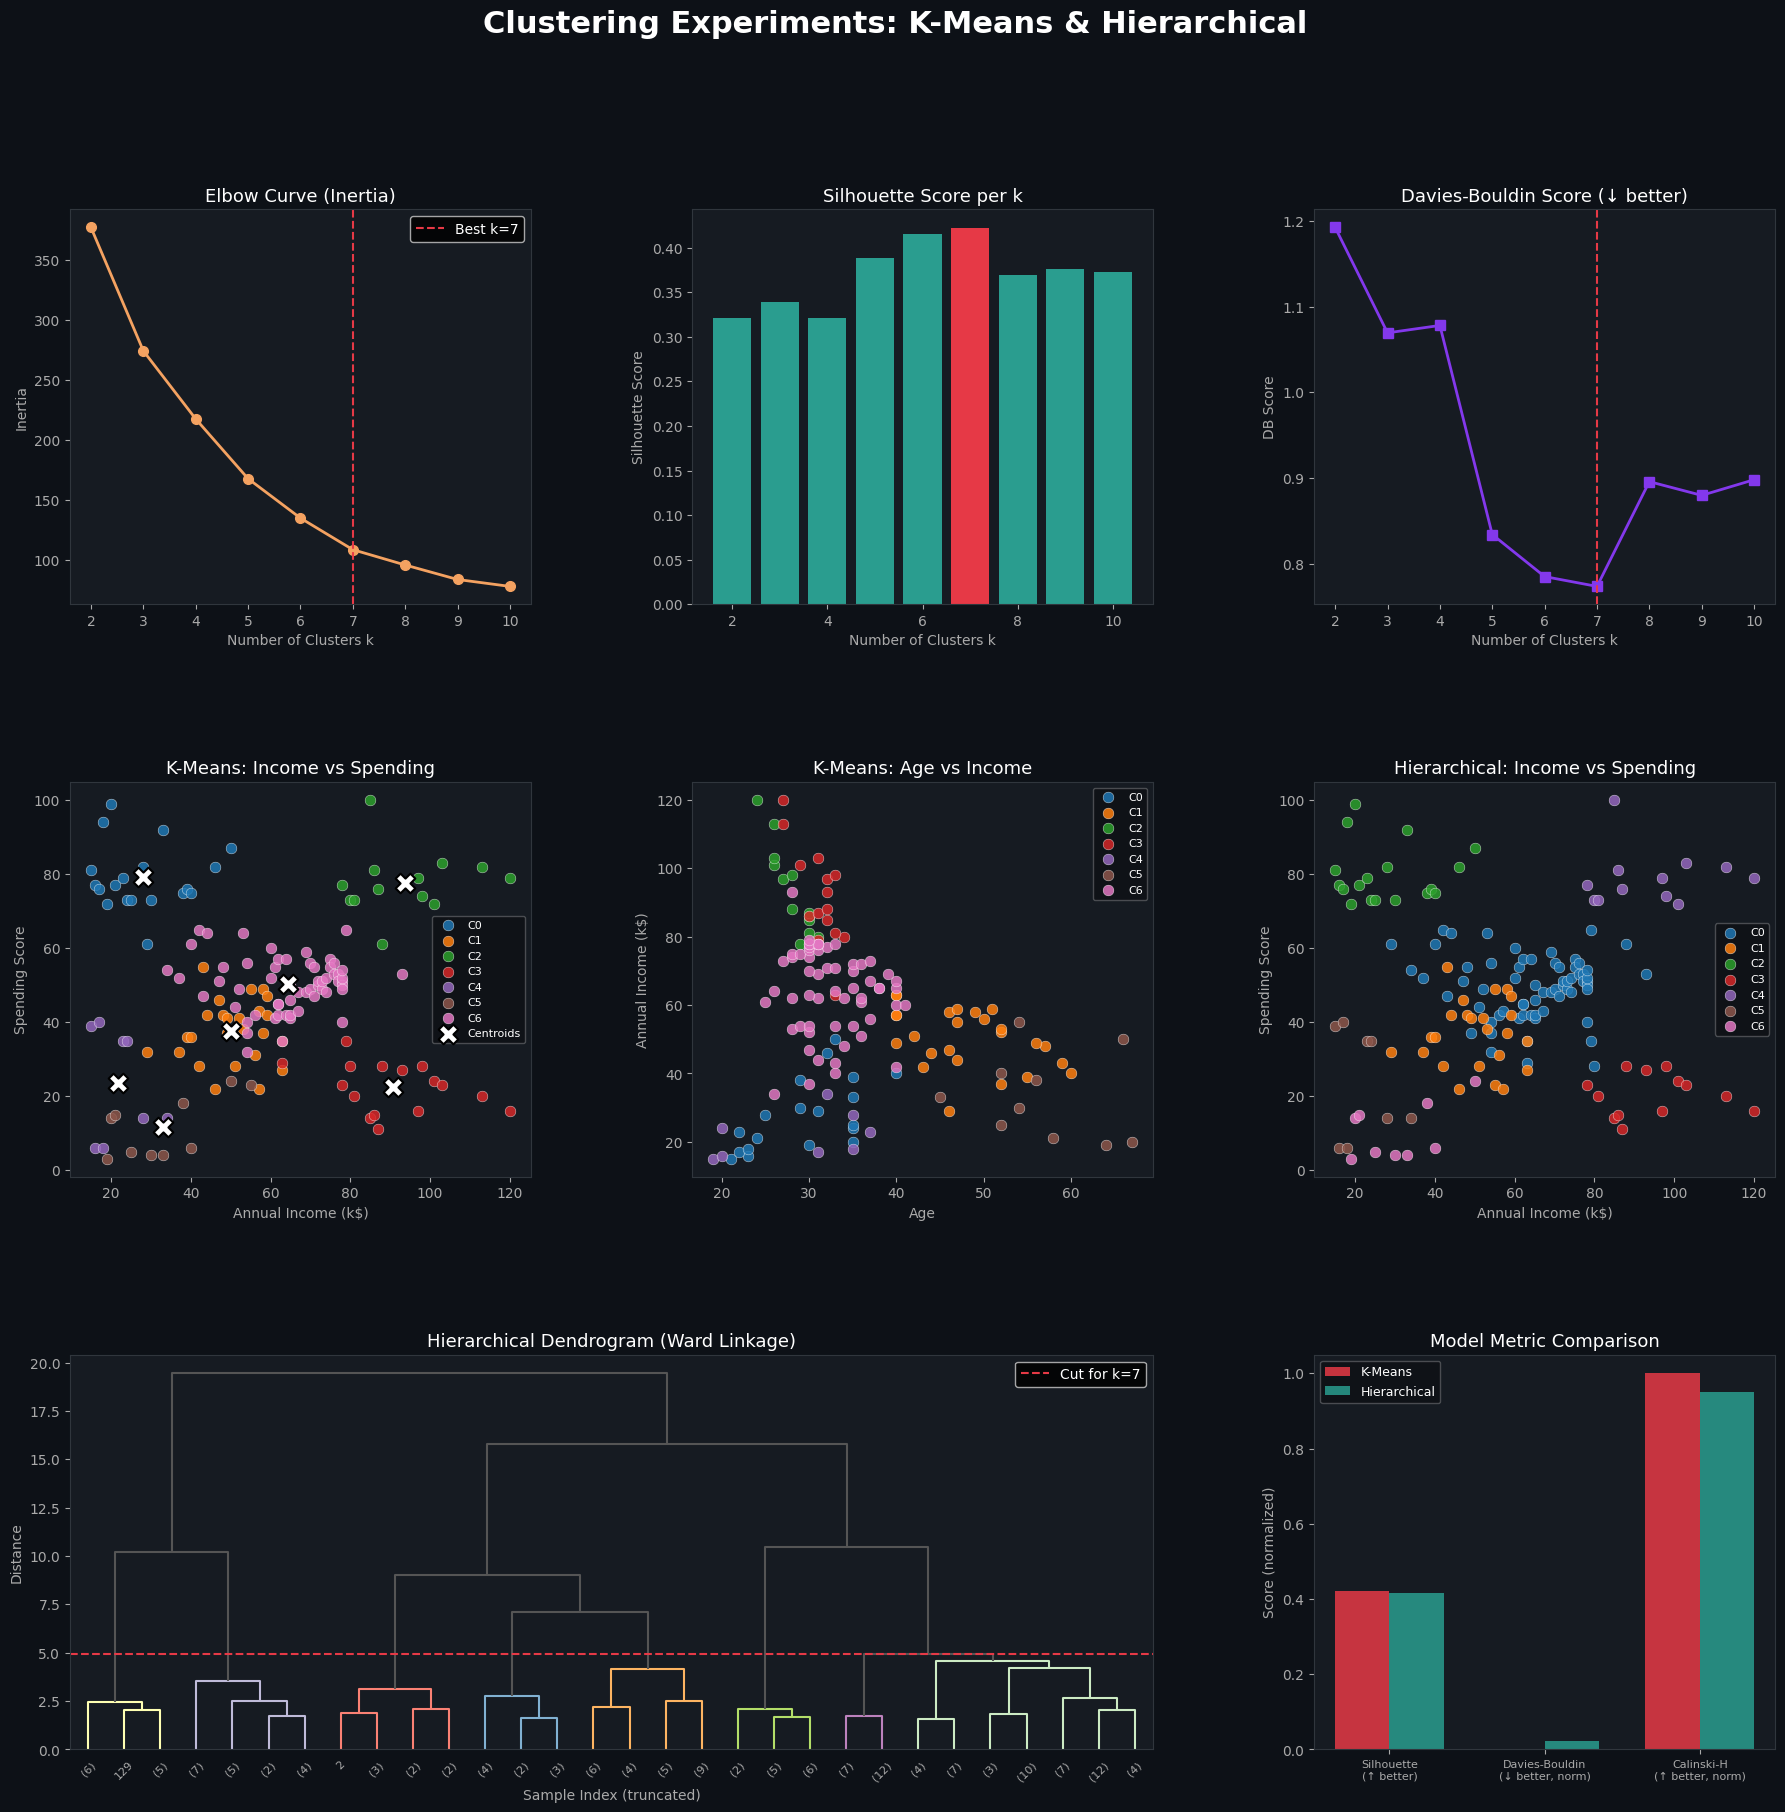

In [ ]:
# 7. VISUALIZATIONS
# ─────────────────────────────────────────────

# FIX 1 & 2: Use colormap so COLORS always has enough entries for any best_k
import matplotlib.cm as cm
COLORS = [cm.tab10(i) for i in range(best_k)]

plt.style.use('dark_background')
fig = plt.figure(figsize=(22, 20), facecolor='#0d1117')
fig.suptitle('Clustering Experiments: K-Means & Hierarchical',
             fontsize=22, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Elbow Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(list(K_range), inertias, 'o-', color='#f4a261', lw=2, ms=7)
ax1.axvline(best_k, color='#e63946', ls='--', lw=1.5, label=f'Best k={best_k}')
ax1.set_title('Elbow Curve (Inertia)', color='white', fontsize=13)
ax1.set_xlabel('Number of Clusters k', color='#aaa')
ax1.set_ylabel('Inertia', color='#aaa')
ax1.tick_params(colors='#aaa')
ax1.legend(fontsize=10)
ax1.set_facecolor('#161b22')
for spine in ax1.spines.values(): spine.set_color('#30363d')

# ── Plot 2: Silhouette Score
# FIX 4: removed unused 'bars =' assignment
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(list(K_range), silhouettes,
        color=[('#e63946' if k == best_k else '#2a9d8f') for k in K_range])
ax2.set_title('Silhouette Score per k', color='white', fontsize=13)
ax2.set_xlabel('Number of Clusters k', color='#aaa')
ax2.set_ylabel('Silhouette Score', color='#aaa')
ax2.tick_params(colors='#aaa')
ax2.set_facecolor('#161b22')
for spine in ax2.spines.values(): spine.set_color('#30363d')

# ── Plot 3: Davies-Bouldin Score
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(list(K_range), db_scores, 's-', color='#8338ec', lw=2, ms=7)
ax3.axvline(best_k, color='#e63946', ls='--', lw=1.5)
ax3.set_title('Davies-Bouldin Score (↓ better)', color='white', fontsize=13)
ax3.set_xlabel('Number of Clusters k', color='#aaa')
ax3.set_ylabel('DB Score', color='#aaa')
ax3.tick_params(colors='#aaa')
ax3.set_facecolor('#161b22')
for spine in ax3.spines.values(): spine.set_color('#30363d')

# ── Plot 4: K-Means scatter (Income vs Spending)
# FIX 1: renamed loop variable from c → i to avoid clash with scatter's c= parameter
# FIX 6: use df[col].values[mask] for safe boolean indexing
ax4 = fig.add_subplot(gs[1, 0])
for i in range(best_k):
    mask = kmeans_labels == i
    ax4.scatter(df['annual_income_k'].values[mask], df['spending_score'].values[mask],
                color=COLORS[i], label=f'C{i}', alpha=0.85, s=60, edgecolors='white', lw=0.3)
# centroids
cx = scaler.inverse_transform(kmeans.cluster_centers_)
ax4.scatter(cx[:,0], cx[:,1], marker='X', s=200, c='white',
            edgecolors='black', lw=1.5, zorder=5, label='Centroids')
ax4.set_title('K-Means: Income vs Spending', color='white', fontsize=13)
ax4.set_xlabel('Annual Income (k$)', color='#aaa')
ax4.set_ylabel('Spending Score', color='#aaa')
ax4.tick_params(colors='#aaa')
ax4.legend(fontsize=8, framealpha=0.3)
ax4.set_facecolor('#161b22')
for spine in ax4.spines.values(): spine.set_color('#30363d')

# ── Plot 5: K-Means scatter (Age vs Income)
# FIX 1 & 6: renamed loop variable i, safe indexing
ax5 = fig.add_subplot(gs[1, 1])
for i in range(best_k):
    mask = kmeans_labels == i
    ax5.scatter(df['age'].values[mask], df['annual_income_k'].values[mask],
                color=COLORS[i], label=f'C{i}', alpha=0.85, s=60, edgecolors='white', lw=0.3)
ax5.set_title('K-Means: Age vs Income', color='white', fontsize=13)
ax5.set_xlabel('Age', color='#aaa')
ax5.set_ylabel('Annual Income (k$)', color='#aaa')
ax5.tick_params(colors='#aaa')
ax5.legend(fontsize=8, framealpha=0.3)
ax5.set_facecolor('#161b22')
for spine in ax5.spines.values(): spine.set_color('#30363d')

# ── Plot 6: Hierarchical scatter (Income vs Spending)
# FIX 1 & 6: renamed loop variable i, safe indexing
ax6 = fig.add_subplot(gs[1, 2])
for i in range(best_k):
    mask = hc_labels == i
    ax6.scatter(df['annual_income_k'].values[mask], df['spending_score'].values[mask],
                color=COLORS[i], label=f'C{i}', alpha=0.85, s=60, edgecolors='white', lw=0.3)
ax6.set_title('Hierarchical: Income vs Spending', color='white', fontsize=13)
ax6.set_xlabel('Annual Income (k$)', color='#aaa')
ax6.set_ylabel('Spending Score', color='#aaa')
ax6.tick_params(colors='#aaa')
ax6.legend(fontsize=8, framealpha=0.3)
ax6.set_facecolor('#161b22')
for spine in ax6.spines.values(): spine.set_color('#30363d')

# ── Plot 7: Dendrogram
# FIX 3: corrected cut index from Z[-best_k+1, 2] → Z[-best_k, 2]
cut_threshold = Z[-best_k, 2]
ax7 = fig.add_subplot(gs[2, :2])
dendrogram(Z, ax=ax7, truncate_mode='lastp', p=30,
           color_threshold=cut_threshold,
           above_threshold_color='#555',
           leaf_font_size=8)
ax7.axhline(cut_threshold, color='#e63946', ls='--', lw=1.5,
            label=f'Cut for k={best_k}')
ax7.set_title('Hierarchical Dendrogram (Ward Linkage)', color='white', fontsize=13)
ax7.set_xlabel('Sample Index (truncated)', color='#aaa')
ax7.set_ylabel('Distance', color='#aaa')
ax7.tick_params(colors='#aaa')
ax7.legend(fontsize=10)
ax7.set_facecolor('#161b22')
for spine in ax7.spines.values(): spine.set_color('#30363d')

# ── Plot 8: Metric Comparison Bar
ax8 = fig.add_subplot(gs[2, 2])
metrics = ['Silhouette\n(↑ better)', 'Davies-Bouldin\n(↓ better, norm)', 'Calinski-H\n(↑ better, norm)']
# Normalize for visual comparison
ch_norm_km = km_ch / max(km_ch, hc_ch)
ch_norm_hc = hc_ch / max(km_ch, hc_ch)
db_norm_km = 1 - km_db / max(km_db, hc_db)   # flip so higher = better
db_norm_hc = 1 - hc_db / max(km_db, hc_db)
km_vals = [km_sil, db_norm_km, ch_norm_km]
hc_vals = [hc_sil, db_norm_hc, ch_norm_hc]
x = np.arange(len(metrics))
w = 0.35
ax8.bar(x - w/2, km_vals, w, label='K-Means', color='#e63946', alpha=0.85)
ax8.bar(x + w/2, hc_vals, w, label='Hierarchical', color='#2a9d8f', alpha=0.85)
ax8.set_title('Model Metric Comparison', color='white', fontsize=13)
ax8.set_xticks(x)
ax8.set_xticklabels(metrics, color='#aaa', fontsize=8)
ax8.set_ylabel('Score (normalized)', color='#aaa')
ax8.tick_params(colors='#aaa')
ax8.legend(fontsize=9, framealpha=0.3)
ax8.set_facecolor('#161b22')
for spine in ax8.spines.values(): spine.set_color('#30363d')

plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
print("\n✅ Plot saved: clustering_results.png")
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# 8. SAVE RESULTS
# ─────────────────────────────────────────────
df.to_csv("clustering_results.csv", index=False)
print("✅ Results saved: clustering_results.csv")

print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"  Dataset         : 150 Mall Customers, 4 features")
print(f"  Optimal k       : {best_k}")
print(f"")
print(f"  K-Means")
print(f"    Silhouette    : {km_sil:.4f}")
print(f"    Davies-Bouldin: {km_db:.4f}")
print(f"    Calinski-H    : {km_ch:.2f}")
print(f"")
print(f"  Hierarchical (Ward)")
print(f"    Silhouette    : {hc_sil:.4f}")
print(f"    Davies-Bouldin: {hc_db:.4f}")
print(f"    Calinski-H    : {hc_ch:.2f}")
print("=" * 60)

✅ Results saved: clustering_results.csv

  SUMMARY
  Dataset         : 150 Mall Customers, 4 features
  Optimal k       : 7

  K-Means
    Silhouette    : 0.4218
    Davies-Bouldin: 0.7734
    Calinski-H    : 107.40

  Hierarchical (Ward)
    Silhouette    : 0.4162
    Davies-Bouldin: 0.7568
    Calinski-H    : 101.96


# **MLDL Lab No. 10**

Saving images.jfif to images.jfif
Original Image:


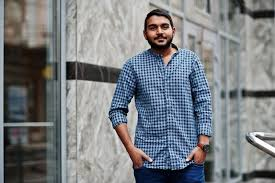

Grayscale Image:


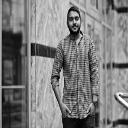

Noisy Image:


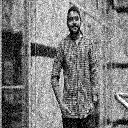

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0458
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0443
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0432
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0421
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.0406
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0386
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0358
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0323
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0280
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0235
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0194
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0173
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0181
Epoch 14/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0209
Epoch 15/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0241
Epoch 16/30
1/1 ━━━━━━

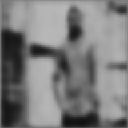

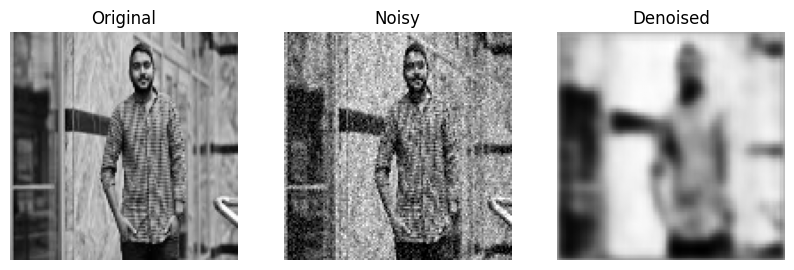

In [34]:
# Install
# !pip install tensorflow opencv-python

# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow
from tensorflow.keras import layers, Model

# =========================
# 1. Upload Image
# =========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

if img is None:
    print("Error loading image")
else:
    print("Original Image:")
    cv2_imshow(img)

# =========================
# 2. Preprocess
# =========================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (128, 128))
img = img / 255.0

print("Grayscale Image:")
cv2_imshow((img * 255).astype(np.uint8))

# =========================
# 3. Add Noise
# =========================
noise = np.random.normal(0, 0.1, img.shape)
noisy_img = img + noise
noisy_img = np.clip(noisy_img, 0., 1.)

print("Noisy Image:")
cv2_imshow((noisy_img * 255).astype(np.uint8))

# =========================
# 4. Build Autoencoder
# =========================
input_img = layers.Input(shape=(128, 128, 1))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

output = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, output)
autoencoder.compile(optimizer='adam', loss='mse')

# =========================
# 5. Train
# =========================
clean = img.reshape(1,128,128,1)
noisy = noisy_img.reshape(1,128,128,1)

autoencoder.fit(noisy, clean, epochs=30, verbose=1)

# =========================
# 6. Denoise
# =========================
denoised = autoencoder.predict(noisy)
denoised = denoised.reshape(128,128)

print("Denoised Image:")
cv2_imshow((denoised * 255).astype(np.uint8))

# =========================
# 7. Comparison Plot
# =========================
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Noisy")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Denoised")
plt.imshow(denoised, cmap='gray')
plt.axis('off')

plt.show()

# =========================
# 8. Download Output
# =========================
# cv2.imwrite("cleaned_image.jpg", (denoised*255).astype(np.uint8))
# files.download("cleaned_image.jpg")

In [ ]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# =========================
# 2. Load Dataset
# =========================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# =========================
# 3. Add Noise
# =========================
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# =========================
# 4. Autoencoder Model
# =========================
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Full Autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# =========================
# 5. Create Encoder Model
# =========================
encoder = Model(input_img, encoded)

# =========================
# 6. Create Decoder Model
# =========================
encoded_input = Input(shape=(7, 7, 32))

decoder_layer = autoencoder.layers[-3](encoded_input)
decoder_layer = autoencoder.layers[-2](decoder_layer)
decoder_output = autoencoder.layers[-1](decoder_layer)

decoder = Model(encoded_input, decoder_output)

# =========================
# 7. Train Model
# =========================
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=5,          # increase to 10 for better result
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# =========================
# 8. Encode & Decode
# =========================
decoded_imgs = autoencoder.predict(x_test_noisy)
encoded_imgs = encoder.predict(x_test_noisy)
# =========================
# 9. Display Results
# =========================
n = 5
plt.figure(figsize=(12,7))

for i in range(n):
    # Noisy
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Original
    plt.subplot(3, n, i+1+n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# 10. Show Encoded Features
# =========================
plt.figure(figsize=(10,4))

for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(encoded_imgs[0][:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Encoded Feature Maps")
plt.show()

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 280ms/step - loss: 0.1719 - val_loss: 0.1189
Epoch 2/5
313/469 ━━━━━━━━━━━━━━━━━━━━ 41s 266ms/step - loss: 0.1180